# Image Captioning with Transformers
You have now implemented a vanilla RNN and for the task of image captioning. In this notebook you will implement key pieces of a transformer decoder to accomplish the same task.

**NOTE:** This notebook will be primarily written in PyTorch rather than NumPy, unlike the RNN notebook. 

In [ ]:
# Setup cell.
import time, os, json
import numpy as np
import matplotlib.pyplot as plt

from sources.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from sources.transformer_layers import *
from sources.captioning_solver_transformer import CaptioningSolverTransformer
from sources.transformer import CaptioningTransformer
from sources.coco_utils import load_coco_data, sample_coco_minibatch, decode_captions
from sources.image_utils import image_from_url

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # Set default size of plots.
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

# COCO Dataset
As in the previous notebooks, we will use the COCO dataset for captioning.

In [ ]:
# Load COCO data from disk into a dictionary.
from sources.coco_utils import *
data = load_coco_data(pca_features=True)

# Print out all the keys and values from the data dictionary.
for k, v in data.items():
    if type(v) == np.ndarray:
        print(k, type(v), v.shape, v.dtype)
    else:
        print(k, type(v), len(v))

# Transformer
As you have seen, RNNs are incredibly powerful but often slow to train. Further, RNNs struggle to encode long-range dependencies (though LSTMs are one way of mitigating the issue). In 2017, Vaswani et al introduced the Transformer in their paper ["Attention Is All You Need"](https://arxiv.org/abs/1706.03762) to a) introduce parallelism and b) allow models to learn long-range dependencies. The paper not only led to famous models like BERT and GPT in the natural language processing community, but also an explosion of interest across fields, including vision. While here we introduce the model in the context of image captioning, the idea of attention itself is much more general.



# Transformer: Multi-Headed Attention

### Dot-Product Attention

Recall that attention can be viewed as an operation on a query $q\in\mathbb{R}^d$, a set of value vectors $\{v_1,\dots,v_n\}, v_i\in\mathbb{R}^d$, and a set of key vectors $\{k_1,\dots,k_n\}, k_i \in \mathbb{R}^d$, specified as

\begin{align}
c &= \sum_{i=1}^{n} v_i \alpha_i \\ \alpha_i &= \frac{\exp(k_i^\top q)}{\sum_{j=1}^{n} \exp(k_j^\top q)} \\
\end{align}

where $\alpha_i$ are frequently called the "attention weights", and the output $c\in\mathbb{R}^d$ is a correspondingly weighted average over the value vectors.

### Self-Attention
In Transformers, we perform self-attention, which means that the values, keys and query are derived from the input $X \in \mathbb{R}^{\ell \times d}$, where $\ell$ is our sequence length. Specifically, we learn parameter matrices $V,K,Q \in \mathbb{R}^{d\times d}$ to map our input $X$ as follows:

\begin{align}
v_i = Vx_i\ \ i \in \{1,\dots,\ell\}\\
k_i = Kx_i\ \ i \in \{1,\dots,\ell\}\\
q_i = Qx_i\ \ i \in \{1,\dots,\ell\}
\end{align}

### Multi-Headed Scaled Dot-Product Attention
In the case of multi-headed attention, we learn a parameter matrix for each head, which gives the model more expressivity to attend to different parts of the input. Let $h$ be number of heads, and $Y_i$ be the attention output of head $i$. Thus we learn individual matrices $Q_i$, $K_i$ and $V_i$. To keep our overall computation the same as the single-headed case, we choose $Q_i \in \mathbb{R}^{d\times d/h}$, $K_i \in \mathbb{R}^{d\times d/h}$ and $V_i \in \mathbb{R}^{d\times d/h}$. Adding in a scaling term $\frac{1}{\sqrt{d/h}}$ to our simple dot-product attention above, we have

\begin{equation}
Y_i = \text{softmax}\bigg(\frac{(XQ_i)(XK_i)^\top}{\sqrt{d/h}}\bigg)(XV_i)
\end{equation}

where $Y_i\in\mathbb{R}^{\ell \times d/h}$, where $\ell$ is our sequence length.

In our implementation, we apply dropout to the attention weights (though in practice it could be used at any step):

\begin{equation}
Y_i = \text{dropout}\bigg(\text{softmax}\bigg(\frac{(XQ_i)(XK_i)^\top}{\sqrt{d/h}}\bigg)\bigg)(XV_i)
\end{equation}

Finally, then the output of the self-attention is a linear transformation of the concatenation of the heads:

\begin{equation}
Y = [Y_1;\dots;Y_h]A
\end{equation}

were $A \in\mathbb{R}^{d\times d}$ and $[Y_1;\dots;Y_h]\in\mathbb{R}^{\ell \times d}$.

Implement multi-headed scaled dot-product attention in the `MultiHeadAttention` class in the file `sources/transformer_layers.py`. The code below will check your implementation. The relative error should be less than `e-2`.

In [ ]:
torch.manual_seed(231)

# Choose dimensions such that they are all unique for easier debugging:
# Specifically, the following values correspond to N=1, H=2, T=3, E//H=4, and E=8.
batch_size = 1
sequence_length = 3
embed_dim = 8
attn = MultiHeadAttention(embed_dim, num_heads=2)
attn.eval()

# Self-attention.
data = torch.randn(batch_size, sequence_length, embed_dim)
self_attn_output = attn(query=data, key=data, value=data)

# Masked self-attention.
mask = torch.randn(sequence_length, sequence_length) < 0.5
masked_self_attn_output = attn(query=data, key=data, value=data, attn_mask=mask)

# Attention using two inputs.
other_data = torch.randn(batch_size, sequence_length, embed_dim)
attn_output = attn(query=data, key=other_data, value=other_data)

expected_self_attn_output = np.asarray(
    [[[-0.1030,  0.2090,  0.7481, -0.4116, -0.2772,  0.2357, -0.2740,
          -0.2798],
         [-0.1794,  0.1637,  0.6930, -0.3435, -0.2300,  0.2457, -0.2504,
          -0.2323],
         [-0.1861,  0.1567,  0.6677, -0.3078, -0.2731,  0.2302, -0.2714,
          -0.2082]]]
)

expected_masked_self_attn_output = np.asarray(
    [[[-0.1209,  0.1806,  0.8056, -0.4654, -0.2262,  0.2552, -0.2544,
          -0.2812],
         [-0.2374,  0.1183,  0.7423, -0.3777, -0.1460,  0.2716, -0.2213,
          -0.2077],
         [-0.0851,  0.2423,  0.7941, -0.3778, -0.4924,  0.1512, -0.4241,
          -0.1740]]]
)

expected_attn_output = np.asarray(
    [[[-0.1965,  0.0702,  0.5227, -0.1388, -0.3530,  0.2163, -0.2643,
          -0.1902],
         [-0.3592, -0.0899,  0.5836,  0.0029, -0.3643,  0.2667, -0.1973,
          -0.1698],
         [-0.3795,  0.0433,  0.5634, -0.0749, -0.4379,  0.2714, -0.2207,
          -0.1980]]]
)

print('self_attn_output error: ', rel_error(expected_self_attn_output, self_attn_output.detach().numpy()))
print('masked_self_attn_output error: ', rel_error(expected_masked_self_attn_output, masked_self_attn_output.detach().numpy()))
print('attn_output error: ', rel_error(expected_attn_output, attn_output.detach().numpy()))

# Positional Encoding

While transformers are able to easily attend to any part of their input, the attention mechanism has no concept of token order. However, for many tasks (especially natural language processing), relative token order is very important. To recover this, the authors add a positional encoding to the embeddings of individual word tokens.

Let us define a matrix $P \in \mathbb{R}^{l\times d}$, where $P_{ij} = $

$$
\begin{cases}
\text{sin}\left(i \cdot 10000^{-\frac{j}{d}}\right) & \text{if j is even} \\
\text{cos}\left(i \cdot 10000^{-\frac{(j-1)}{d}}\right) & \text{otherwise} \\
\end{cases}
$$

Rather than directly passing an input $X \in \mathbb{R}^{l\times d}$ to our network, we instead pass $X + P$.

Implement this layer in `PositionalEncoding` in `sources/transformer_layers.py`. Once you are done, run the following to perform a simple test of your implementation. You should see errors on the order of `e-3` or less.

In [ ]:
torch.manual_seed(231)

batch_size = 1
sequence_length = 2
embed_dim = 6
data = torch.randn(batch_size, sequence_length, embed_dim)

pos_encoder = PositionalEncoding(embed_dim)
pos_encoder.eval()
output = pos_encoder(data)

expected_pe_output = np.asarray(
    [[[-1.1106,  1.0014,  1.5280, -0.0778, -0.6964,  1.1455],
         [ 0.8125, -0.4303,  0.4981,  0.7320,  1.1380,  1.5331]]]
)

print('pe_output error: ', rel_error(expected_pe_output, output.detach().numpy()))

# Transformer for Image Captioning
Now that you have implemented the previous layers, you can combine them to build a Transformer-based image captioning model. Open the file `sources/transformer.py` and look at the `CaptioningTransformer` class.

Implement the `forward` function of the class. After doing so, run the following to check your forward pass using a small test case; you should see error on the order of `e-5` or less.

In [ ]:
torch.manual_seed(231)
np.random.seed(231)

N, D, W = 4, 20, 30
word_to_idx = {'<NULL>': 0, 'cat': 2, 'dog': 3}
V = len(word_to_idx)
T = 3

transformer = CaptioningTransformer(
    word_to_idx,
    input_dim=D,
    wordvec_dim=W,
    num_heads=2,
    num_blocks=2,
    max_length=30
)
transformer.eval()

# Set all model parameters to fixed values
for p in transformer.parameters():
    p.data = torch.tensor(np.linspace(-1.4, 1.3, num=p.numel()).reshape(*p.shape))

features = torch.tensor(np.linspace(-1.5, 0.3, num=(N * D)).reshape(N, D))
captions = torch.tensor((np.arange(N * T) % V).reshape(N, T))

scores = transformer(features, captions)

expected_scores = np.asarray(
    [[[-17.2172,   4.7701,  26.7574],
         [-17.2172,   4.7701,  26.7574],
         [-17.2172,   4.7701,  26.7574]],

        [[-17.2172,   4.7701,  26.7574],
         [-17.2172,   4.7701,  26.7574],
         [-17.2172,   4.7701,  26.7574]],

        [[-17.2172,   4.7701,  26.7574],
         [-17.2172,   4.7701,  26.7574],
         [-17.2172,   4.7701,  26.7574]],

        [[-17.2166,   4.7707,  26.7580],
         [-17.2166,   4.7707,  26.7580],
         [-17.2166,   4.7707,  26.7580]]]
)
print('scores error: ', rel_error(expected_scores, scores.detach().numpy()))

# Overfit Transformer Captioning Model on Small Data
Run the following to overfit the Transformer-based captioning model on the same small dataset as we used for the RNN previously.

In [ ]:
torch.manual_seed(231)
np.random.seed(231)

data = load_coco_data(max_train=50)

transformer = CaptioningTransformer(
          word_to_idx=data['word_to_idx'],
          input_dim=data['train_features'].shape[1],
          wordvec_dim=256,
          num_heads=2,
          num_blocks=2,
          max_length=30
        )


transformer_solver = CaptioningSolverTransformer(transformer, data, idx_to_word=data['idx_to_word'],
           num_epochs=100,
           batch_size=25,
           learning_rate=0.001,
           verbose=True, print_every=10,
         )

transformer_solver.train()

# Plot the training losses.
plt.plot(transformer_solver.loss_history)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training loss history')
plt.show()

Print final training loss. You should see a final loss of less than 0.03.

In [ ]:
print('Final loss: ', transformer_solver.loss_history[-1])

# Transformer Sampling at Test Time
The sampling code has been written for you. You can simply run the following to compare with the previous results with the RNN. As before the training results should be much better than the validation set results, given how little data we trained on.

In [ ]:
# If you get an error, the URL just no longer exists, so don't worry!
# You can re-sample as many times as you want.
for split in ['train', 'val']:
    minibatch = sample_coco_minibatch(data, split=split, batch_size=2)
    gt_captions, features, urls = minibatch
    gt_captions = decode_captions(gt_captions, data['idx_to_word'])

    sample_captions = transformer.sample(features, max_length=30)
    sample_captions = decode_captions(sample_captions, data['idx_to_word'])

    for gt_caption, sample_caption, url in zip(gt_captions, sample_captions, urls):
        img = image_from_url(url)
        # Skip missing URLs.
        if img is None: continue
        plt.imshow(img)            
        plt.title('%s\n%s\nGT:%s' % (split, sample_caption, gt_caption))
        plt.axis('off')
        plt.show()

# Open Chanllenge: Train a Good Transformer model
The results are not satisfactory. One reason is that the model is too simple and sallow (`wordvec_dim=256` `num_heads=2` `num_blocks=2`). 
However, the original Transformer (2017) uses `wordvec_dim=1024` `num_heads=16` `num_blocks=12`, while GPT-2 (2019) uses `wordvec_dim=1600` `num_heads=25` `num_blocks=48`. 
Another reason is that the training set is a small one with a capacity of only 50.

Here we want you to try different architecture and larger training set. Do your best to train a good model, then sample again and see if it gets better results.

Hints: 
1. be careful with large hyperparameters because your device may run out of memory.
2. A GPU would help accelerate this process. 


In [ ]:
data = load_coco_data(max_train=50)

# change the hyper-parameters below to change the architecture.
transformer = CaptioningTransformer(
          word_to_idx=data['word_to_idx'],
          input_dim=data['train_features'].shape[1],
          wordvec_dim=256,
          num_heads=2,
          num_blocks=2,
          max_length=30
        )

# change the parameter
transformer_solver = CaptioningSolverTransformer(transformer, data, idx_to_word=data['idx_to_word'],
           num_epochs=100,
           batch_size=25,
           learning_rate=0.001,
           verbose=True, print_every=10,
         )

transformer_solver.train()

# Plot the training losses.
plt.plot(transformer_solver.loss_history)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training loss history')
plt.show()

for split in ['train', 'val']:
    minibatch = sample_coco_minibatch(data, split=split, batch_size=2)
    gt_captions, features, urls = minibatch
    gt_captions = decode_captions(gt_captions, data['idx_to_word'])

    sample_captions = transformer.sample(features, max_length=30)
    sample_captions = decode_captions(sample_captions, data['idx_to_word'])

    for gt_caption, sample_caption, url in zip(gt_captions, sample_captions, urls):
        img = image_from_url(url)
        # Skip missing URLs.
        if img is None: continue
        plt.imshow(img)            
        plt.title('%s\n%s\nGT:%s' % (split, sample_caption, gt_caption))
        plt.axis('off')
        plt.show()

# Visualize the Attention Weights
Now that you have trained a satisfactory Captioning Transformer model, we want you to finish the visualizing attention task: to show which part in the pic attracts attention of each word in the output captions.
Refer to [1] as an example of this task. 
You may read through [1] and see how it produces visual attentions as pics below.
But You don't need to produce pics totally the same.

[1] Xu et al, “Show, Attend, and Tell: Neural Image Caption Generation with Visual Attention”, ICML 2015


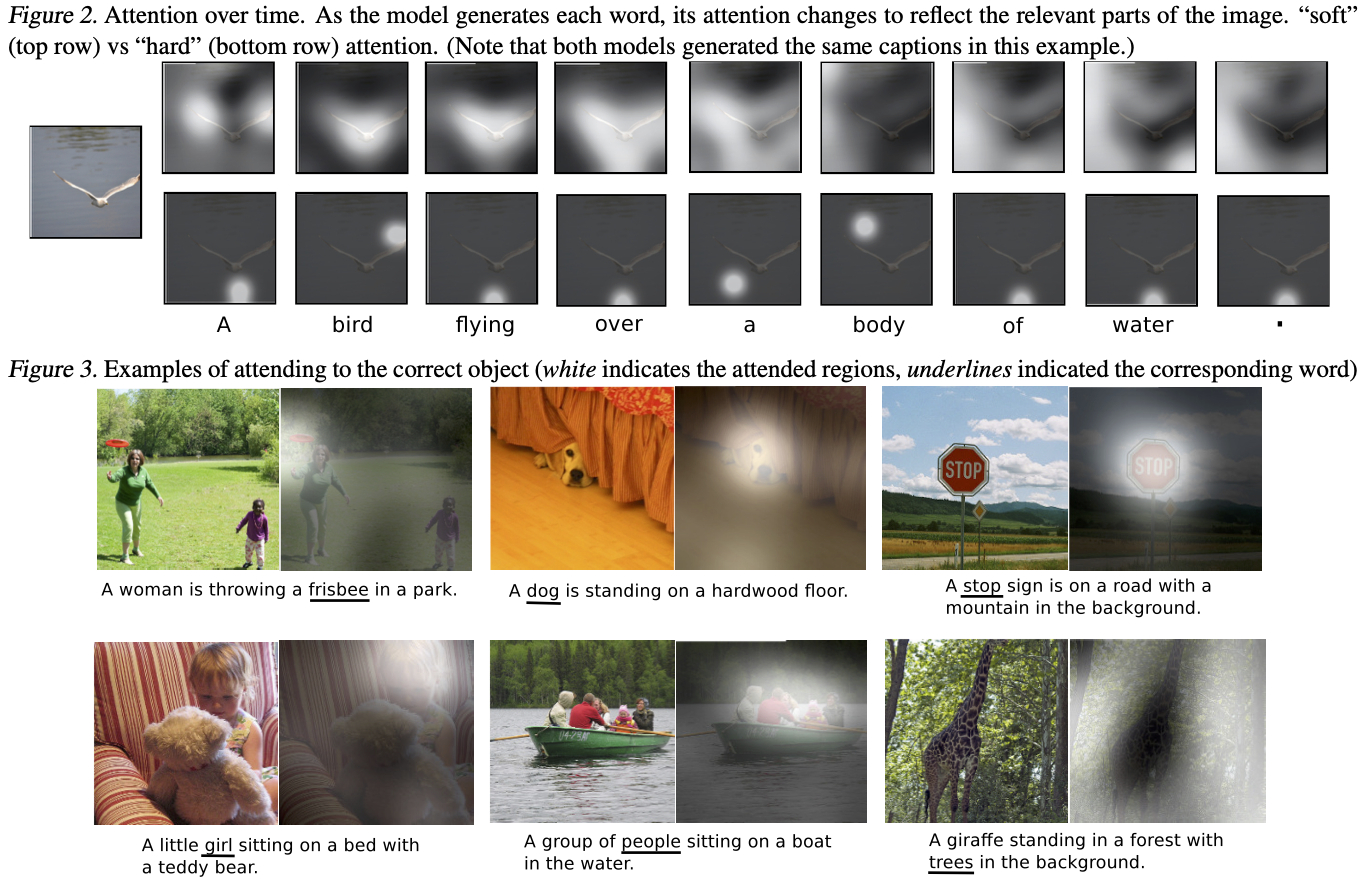

So this is the final task: Visualize the attention weight from your last trained model.
It is a tough task because we didn't prepare any codes for you. 
However, there are a few hints: 
1. Read through `load_coco_data()` and you will find the encoding features come from `fc7` layer in the pretrained `vgg16`. Be careful if you set `pca_features=True`. 
2. If needed, you may change the architecture of `CaptioningTransformer` to better fit the task. For example, the way how the image feature are embeded into Transformer Decoder.
3. Receptive Field may help.

We want you to act like a creative researcher and try your best to independently solve any problem occurring to you. Learn to use web search, you can find answers of any question. When there is no answer, you should create one.
In that case, this will become an interesting task.

In [ ]:
# TODO: Visualize the attention weight from your last trained model
# *****START OF YOUR CODE *****

pass

# *****END OF YOUR CODE *****